In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder


import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
import kagglehub
path = kagglehub.dataset_download("pankajjsh06/ibm-watson-marketing-customer-value-data")
print("Path to dataset files:", path)
df = pd.read_csv(path + "/WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv")
df.head()

print(f" Размер датасета: {df.shape}")
df.head()

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\pankajjsh06\ibm-watson-marketing-customer-value-data\versions\1
 Размер датасета: (9134, 24)


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [3]:
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропущенные значения:\n{df.isnull().sum()}")
print(f"\nДубликаты: {df.duplicated().sum()}")
df.describe().T

Количество строк: 9134
Количество столбцов: 24

Типы данных:
Customer                          object
State                             object
Customer Lifetime Value          float64
Response                          object
Coverage                          object
Education                         object
Effective To Date                 object
EmploymentStatus                  object
Gender                            object
Income                             int64
Location Code                     object
Marital Status                    object
Monthly Premium Auto               int64
Months Since Last Claim            int64
Months Since Policy Inception      int64
Number of Open Complaints          int64
Number of Policies                 int64
Policy Type                       object
Policy                            object
Renew Offer Type                  object
Sales Channel                     object
Total Claim Amount               float64
Vehicle Class                     obj

,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,9134.0,8004.940475,6870.967608,1898.007675,3994.251794,5780.182197,8962.167041,83325.381190
Income,9134.0,37657.380009,30379.904734,0.000000,0.000000,33889.500000,62320.000000,99981.000000
Monthly Premium Auto,9134.0,93.219291,34.407967,61.000000,68.000000,83.000000,109.000000,298.000000
Months Since Last Claim,9134.0,15.097000,10.073257,0.000000,6.000000,14.000000,23.000000,35.000000
Months Since Policy Inception,9134.0,48.064594,27.905991,0.000000,24.000000,48.000000,71.000000,99.000000
Number of Open Complaints,9134.0,0.384388,0.910384,0.000000,0.000000,0.000000,0.000000,5.000000
Number of Policies,9134.0,2.966170,2.390182,1.000000,1.000000,2.000000,4.000000,9.000000
Total Claim Amount,9134.0,434.088794,290.500092,0.099007,272.258244,383.945434,547.514839,2893.239678


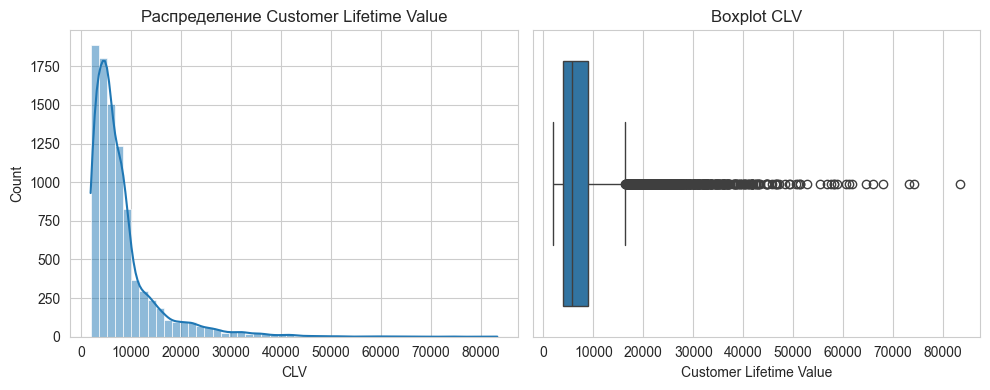

 Целевая переменная:
   Среднее: $8004.94
   Медиана: $5780.18
   Std: $6870.97


In [4]:
#Анализ целевой переменной (Customer Lifetime Value)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Customer Lifetime Value'], bins=50, kde=True)
plt.title('Распределение Customer Lifetime Value')
plt.xlabel('CLV')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Customer Lifetime Value'])
plt.title('Boxplot CLV')
plt.tight_layout()
plt.show()

print(f" Целевая переменная:")
print(f"   Среднее: ${df['Customer Lifetime Value'].mean():.2f}")
print(f"   Медиана: ${df['Customer Lifetime Value'].median():.2f}")
print(f"   Std: ${df['Customer Lifetime Value'].std():.2f}")


📋 Категориальные признаки: ['Customer', 'State', 'Response', 'Coverage', 'Education', 'Effective To Date', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size']


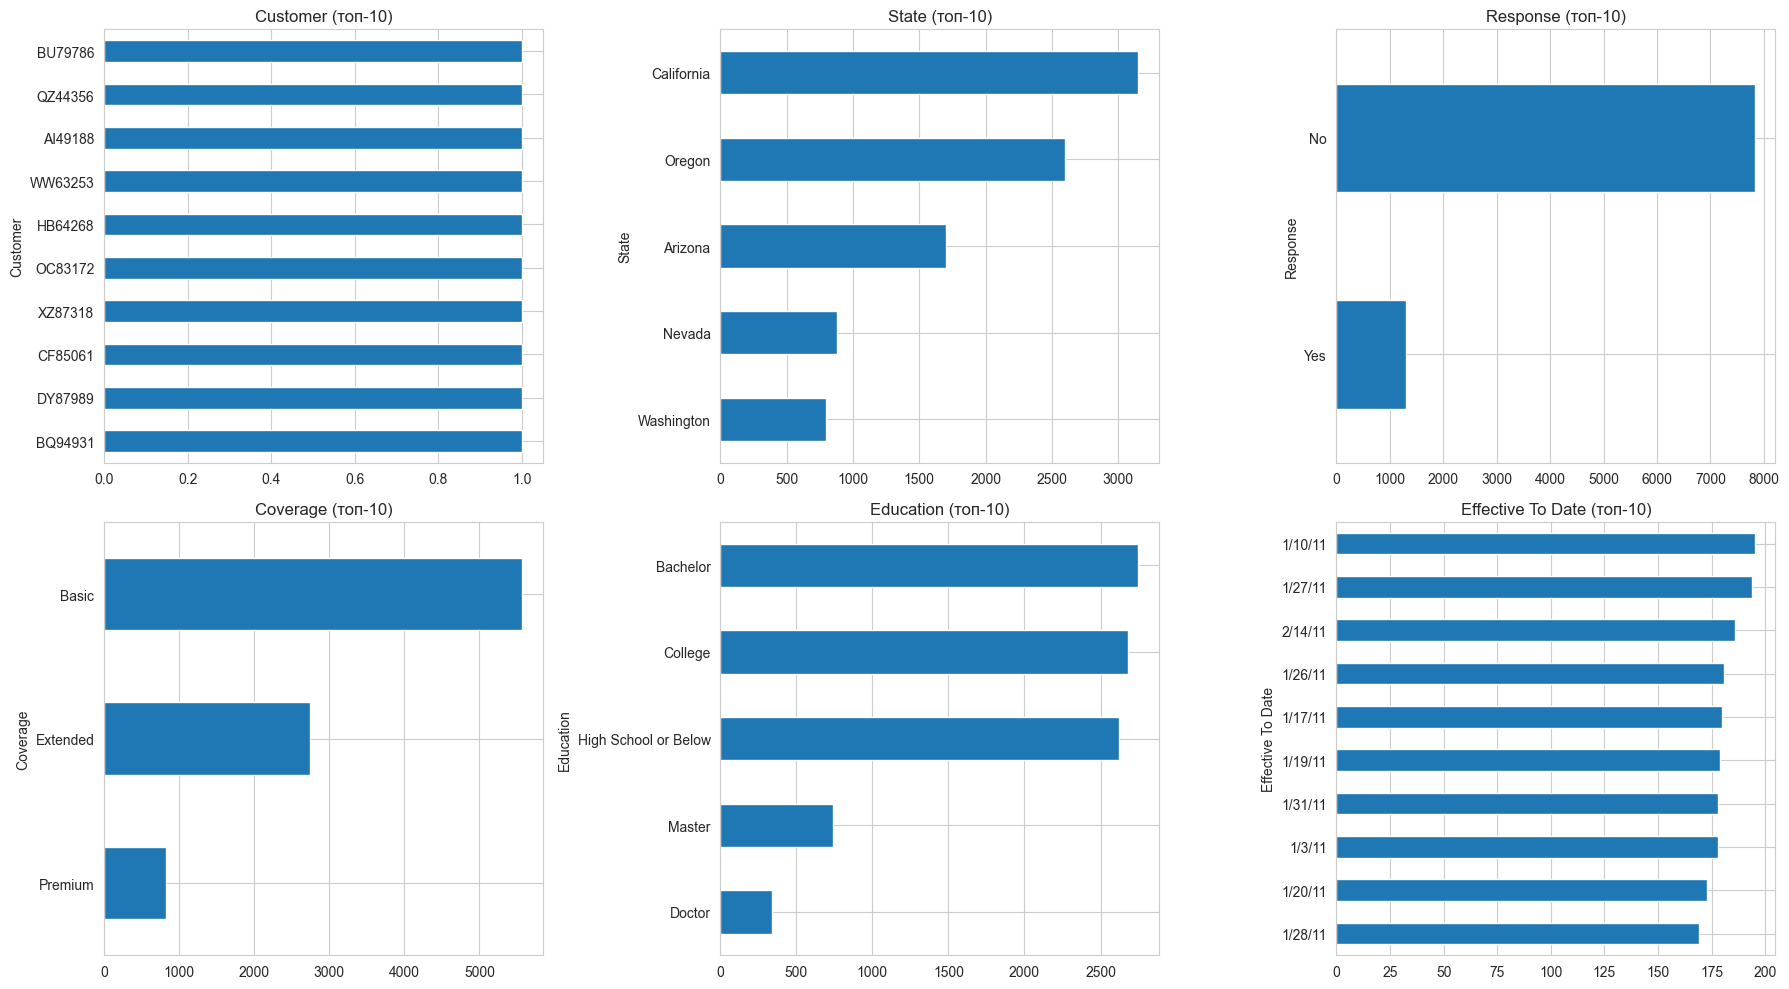

In [5]:
#Анализ категориальных признаков
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n📋 Категориальные признаки: {categorical_cols}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:6]):
    df[col].value_counts().head(10).plot(kind='barh', ax=axes[idx])
    axes[idx].set_title(f'{col} (топ-10)')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()


 Корреляция признаков с целевой переменной:
Customer Lifetime Value          1.000000
Monthly Premium Auto             0.396262
Total Claim Amount               0.226451
Income                           0.024366
Number of Policies               0.021955
Months Since Last Claim          0.011517
Months Since Policy Inception    0.009418
Number of Open Complaints       -0.036343
Name: Customer Lifetime Value, dtype: float64


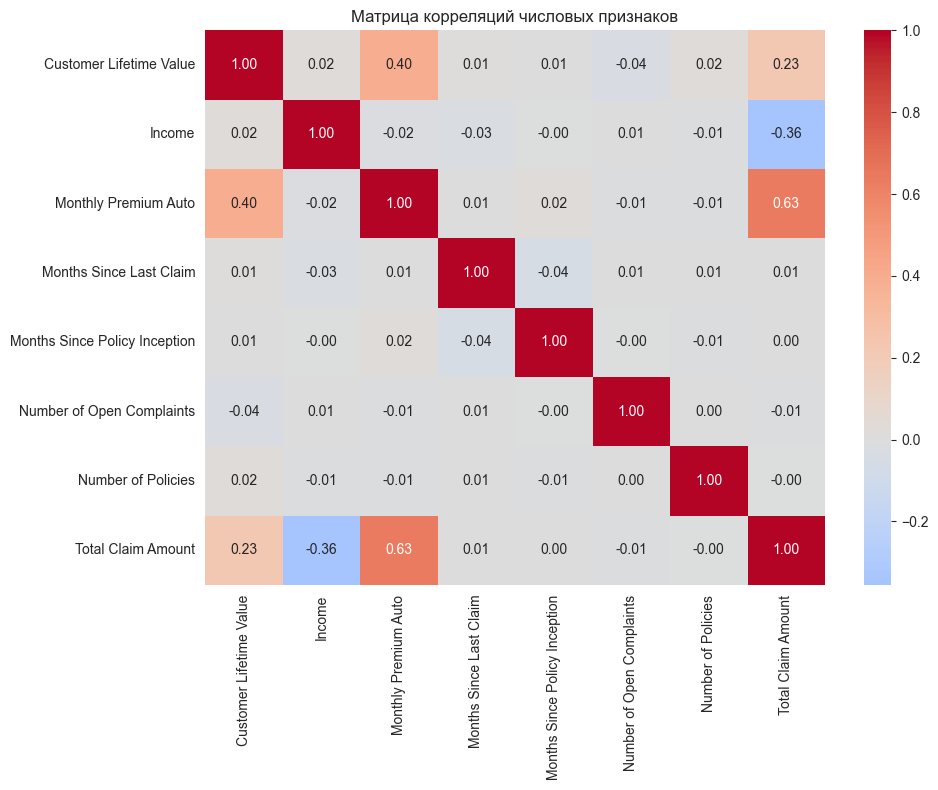

In [6]:
#Корреляция числовых признаков с целевой переменной
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()['Customer Lifetime Value'].sort_values(ascending=False)

print("\n Корреляция признаков с целевой переменной:")
print(correlation)

# Визуализация корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

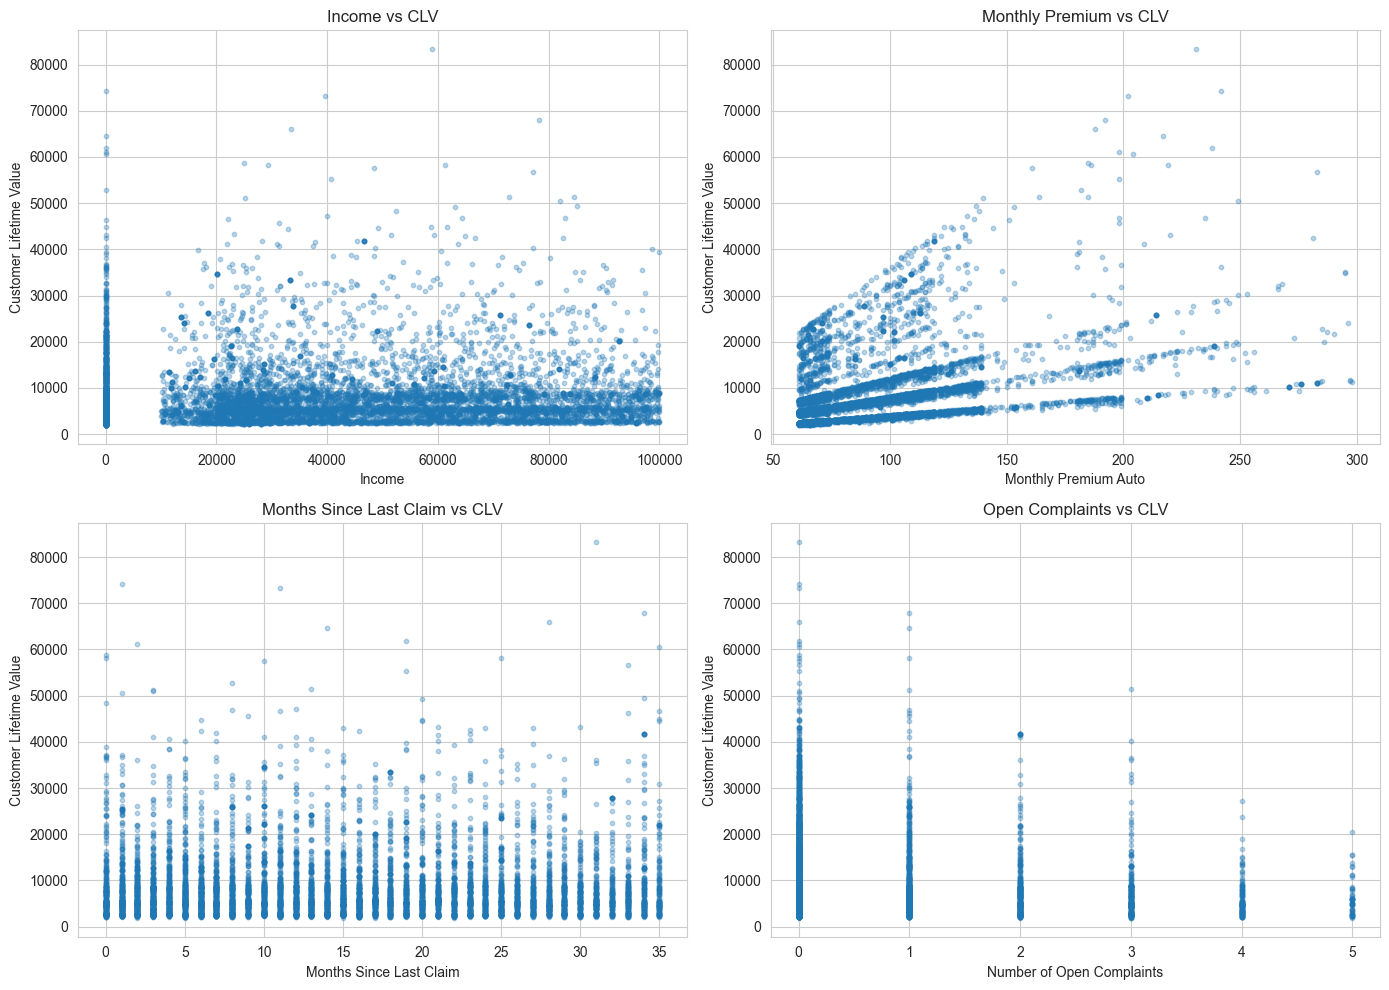

In [7]:
#Зависимости ключевых признаков от целевой переменной
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(df['Income'], df['Customer Lifetime Value'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Income')
axes[0, 0].set_ylabel('Customer Lifetime Value')
axes[0, 0].set_title('Income vs CLV')

axes[0, 1].scatter(df['Monthly Premium Auto'], df['Customer Lifetime Value'], alpha=0.3, s=10)
axes[0, 1].set_xlabel('Monthly Premium Auto')
axes[0, 1].set_ylabel('Customer Lifetime Value')
axes[0, 1].set_title('Monthly Premium vs CLV')

axes[1, 0].scatter(df['Months Since Last Claim'], df['Customer Lifetime Value'], alpha=0.3, s=10)
axes[1, 0].set_xlabel('Months Since Last Claim')
axes[1, 0].set_ylabel('Customer Lifetime Value')
axes[1, 0].set_title('Months Since Last Claim vs CLV')

axes[1, 1].scatter(df['Number of Open Complaints'], df['Customer Lifetime Value'], alpha=0.3, s=10)
axes[1, 1].set_xlabel('Number of Open Complaints')
axes[1, 1].set_ylabel('Customer Lifetime Value')
axes[1, 1].set_title('Open Complaints vs CLV')

plt.tight_layout()
plt.show()

In [8]:
# Создаем копию датасета для обработки
df_processed = df.copy()

# 2.1 Очистка данных: удаляем строки с пропусками в целевой переменной
df_processed = df_processed.dropna(subset=['Customer Lifetime Value'])
print(f"Удалены пропуски в целевой переменной. Осталось: {len(df_processed)} строк")

# 2.2 Обработка целевой переменной: убираем знак '$' и приводим к float
if df_processed['Customer Lifetime Value'].dtype == object:
    df_processed['Customer Lifetime Value'] = df_processed['Customer Lifetime Value'].str.replace('$', '', regex=False)
    df_processed['Customer Lifetime Value'] = df_processed['Customer Lifetime Value'].str.replace(',', '', regex=False)
    df_processed['Customer Lifetime Value'] = pd.to_numeric(df_processed['Customer Lifetime Value'], errors='coerce')

# Удаляем строки с некорректными значениями целевой переменной
df_processed = df_processed.dropna(subset=['Customer Lifetime Value'])
print(f"Целевая переменная преобразована в числовой формат")

Удалены пропуски в целевой переменной. Осталось: 9134 строк
Целевая переменная преобразована в числовой формат


In [9]:
#Feature Engineering: создаём новые признаки

# Отношение премии к доходу (если доход > 0)
df_processed['Premium_to_Income'] = df_processed.apply(
    lambda x: x['Monthly Premium Auto'] / (x['Income'] / 12) if x['Income'] > 0 else 0, axis=1
)

# Общая длительность полиса в месяцах
df_processed['Total_Months'] = df_processed['Months Since Policy Inception'] + df_processed['Months Since Last Claim']

# Индекс лояльности (обратная зависимость от количества жалоб)
df_processed['Loyalty_Index'] = 1 / (1 + df_processed['Number of Open Complaints'])

# Категориальный признак "Высокий доход"
df_processed['High_Income'] = (df_processed['Income'] > df_processed['Income'].median()).astype(int)

In [10]:
#Кодирование категориальных переменных с помощью LabelEncoder
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()
# Исключаем целевую переменную из кодирования
if 'Customer Lifetime Value' in categorical_features:
    categorical_features.remove('Customer Lifetime Value')

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Заполняем пропуски перед кодированием
    df_processed[col] = df_processed[col].fillna('Unknown')
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"Закодирован признак '{col}': {len(le.classes_)} уникальных значений")

# Удаляем исходные категориальные столбцы
df_encoded = df_processed.drop(columns=categorical_features)
print(f"Исходные категориальные признаки удалены")

Закодирован признак 'Customer': 9134 уникальных значений
Закодирован признак 'State': 5 уникальных значений
Закодирован признак 'Response': 2 уникальных значений
Закодирован признак 'Coverage': 3 уникальных значений
Закодирован признак 'Education': 5 уникальных значений
Закодирован признак 'Effective To Date': 59 уникальных значений
Закодирован признак 'EmploymentStatus': 5 уникальных значений
Закодирован признак 'Gender': 2 уникальных значений
Закодирован признак 'Location Code': 3 уникальных значений
Закодирован признак 'Marital Status': 3 уникальных значений
Закодирован признак 'Policy Type': 3 уникальных значений
Закодирован признак 'Policy': 9 уникальных значений
Закодирован признак 'Renew Offer Type': 4 уникальных значений
Закодирован признак 'Sales Channel': 4 уникальных значений
Закодирован признак 'Vehicle Class': 6 уникальных значений
Закодирован признак 'Vehicle Size': 3 уникальных значений
Исходные категориальные признаки удалены


In [11]:
# Определяем целевую переменную
y = df_encoded['Customer Lifetime Value']

# Исключаем неинформативные признаки
exclude_cols = ['Customer', 'Customer Lifetime Value', 'Policy', 'Location Code']
X = df_encoded.drop(columns=[col for col in exclude_cols if col in df_encoded.columns])

# Удаляем признаки с нулевой дисперсией
X = X.loc[:, X.std() > 0]

print(f"Финальный набор: {X.shape[1]} признаков, {X.shape[0]} наблюдений")
print(f"Признаки: {list(X.columns)}")

Финальный набор: 27 признаков, 9134 наблюдений
Признаки: ['Income', 'Monthly Premium Auto', 'Months Since Last Claim', 'Months Since Policy Inception', 'Number of Open Complaints', 'Number of Policies', 'Total Claim Amount', 'Premium_to_Income', 'Total_Months', 'Loyalty_Index', 'High_Income', 'Customer_encoded', 'State_encoded', 'Response_encoded', 'Coverage_encoded', 'Education_encoded', 'Effective To Date_encoded', 'EmploymentStatus_encoded', 'Gender_encoded', 'Location Code_encoded', 'Marital Status_encoded', 'Policy Type_encoded', 'Policy_encoded', 'Renew Offer Type_encoded', 'Sales Channel_encoded', 'Vehicle Class_encoded', 'Vehicle Size_encoded']


In [12]:
#Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Целевая переменная: min={y.min():.2f}, max={y.max():.2f}")

Train: (6393, 27), Test: (2741, 27)
Целевая переменная: min=1898.01, max=83325.38


In [13]:
# Функция для оценки качества моделей
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n {model_name}:")
    print(f"   MAE:  ${mae:,.2f}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_default = {}

In [14]:
# Gradient Boosting из sklearn (по умолчанию)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Обучение GradientBoostingRegressor (sklearn)...")
gb_sklearn = GradientBoostingRegressor(random_state=42)
gb_sklearn.fit(X_train, y_train)
y_pred_gb = gb_sklearn.predict(X_test)
results_default['Sklearn_GB'] = evaluate_model(y_test, y_pred_gb, 'Sklearn GradientBoosting')

Обучение GradientBoostingRegressor (sklearn)...

 Sklearn GradientBoosting:
   MAE:  $1,768.17
   RMSE: $4,108.79
   R²:   0.6756


In [15]:
print("Обучение LightGBM...")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
results_default['LightGBM'] = evaluate_model(y_test, y_pred_lgb, 'LightGBM')

Обучение LightGBM...

 LightGBM:
   MAE:  $1,599.34
   RMSE: $4,020.44
   R²:   0.6894


In [16]:
print("Обучение CatBoost...")
cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0,
    allow_writing_files=False
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
results_default['CatBoost'] = evaluate_model(y_test, y_pred_cat, 'CatBoost')

Обучение CatBoost...

 CatBoost:
   MAE:  $1,768.60
   RMSE: $3,941.33
   R²:   0.7015


СРАВНЕНИЕ МОДЕЛЕЙ (дефолтные гиперпараметры)
                    MAE         RMSE        R2
CatBoost    1768.603775  3941.330237  0.701493
LightGBM    1599.338545  4020.437497  0.689390
Sklearn_GB  1768.168657  4108.792045  0.675588


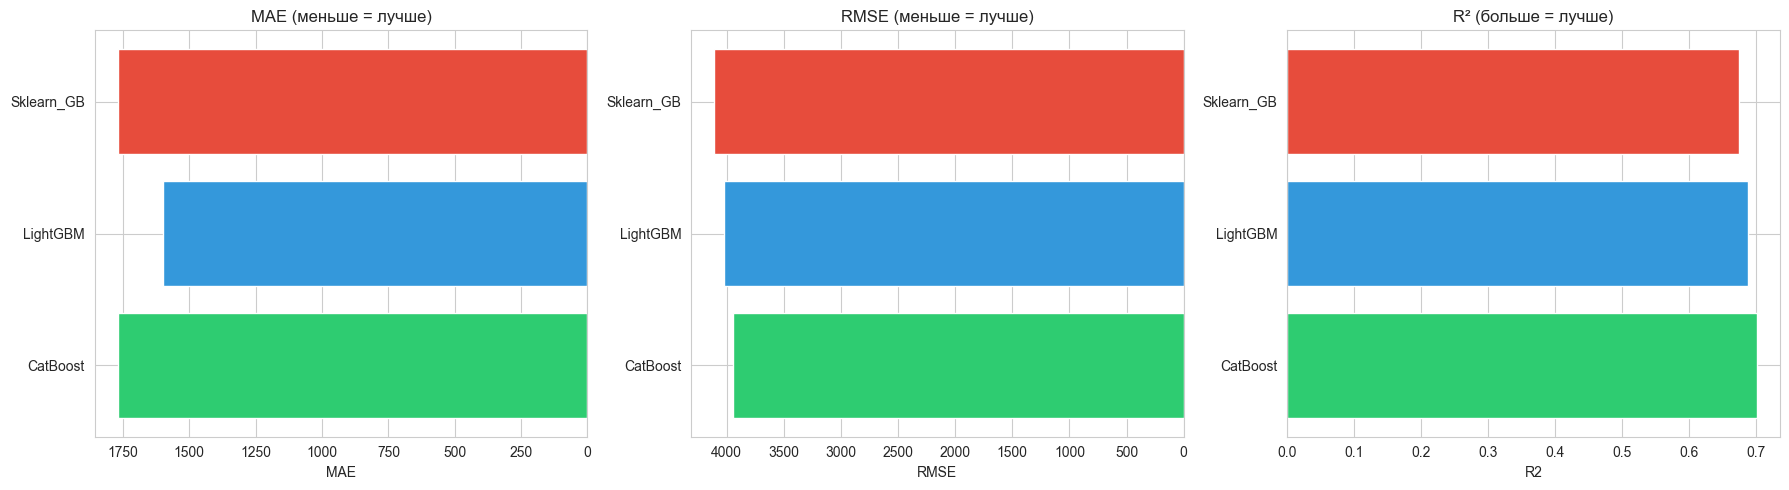

Лидер с дефолтными параметрами: CatBoost (R² = 0.7015)


In [17]:
print("СРАВНЕНИЕ МОДЕЛЕЙ (дефолтные гиперпараметры)")
results_df = pd.DataFrame(results_default).T
results_df = results_df.sort_values('R2', ascending=False)
print(results_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'R2']
titles = ['MAE (меньше = лучше)', 'RMSE (меньше = лучше)', 'R² (больше = лучше)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[idx].barh(results_df.index, results_df[metric],
                          color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(title)
    if metric in ['MAE', 'RMSE']:
        axes[idx].invert_xaxis()  # Для метрик "меньше = лучше"

plt.tight_layout()
plt.show()

# Лидер по умолчанию
best_default = results_df['R2'].idxmax()
print(f"Лидер с дефолтными параметрами: {best_default} (R² = {results_df.loc[best_default, 'R2']:.4f})")

In [18]:
print("НАСТРОЙКА ГИПЕРПАРАМЕТРОВ С КРОСС-ВАЛИДАЦИЕЙ")

# Функция для тюнинга с кросс-валидацией
def tune_model(model, param_grid, X, y, cv=3, scoring='neg_mean_absolute_error'):
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )
    grid_search.fit(X, y)
    return grid_search.best_estimator_, grid_search.best_params_, -grid_search.best_score_

results_tuned = {}

НАСТРОЙКА ГИПЕРПАРАМЕТРОВ С КРОСС-ВАЛИДАЦИЕЙ


In [19]:
print("Настройка Sklearn GradientBoosting...")
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
gb_tuned, gb_best_params, gb_cv_score = tune_model(
    GradientBoostingRegressor(random_state=42),
    gb_params, X_train, y_train
)
y_pred_gb_tuned = gb_tuned.predict(X_test)
results_tuned['Sklearn_GB'] = evaluate_model(y_test, y_pred_gb_tuned, 'Sklearn GB (Tuned)')
print(f"Лучшие параметры: {gb_best_params}")

Настройка Sklearn GradientBoosting...

 Sklearn GB (Tuned):
   MAE:  $1,671.85
   RMSE: $4,104.51
   R²:   0.6763
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


In [20]:
print("Настройка XGBoost...")
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_tuned, xgb_best_params, xgb_cv_score = tune_model(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    xgb_params, X_train, y_train
)
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
results_tuned['XGBoost'] = evaluate_model(y_test, y_pred_xgb_tuned, 'XGBoost (Tuned)')
print(f"Лучшие параметры: {xgb_best_params}")

Настройка XGBoost...

 XGBoost (Tuned):
   MAE:  $1,652.99
   RMSE: $4,062.56
   R²:   0.6828
Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


In [21]:
print("Настройка LightGBM...")
lgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
lgb_tuned, lgb_best_params, lgb_cv_score = tune_model(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgb_params, X_train, y_train
)
y_pred_lgb_tuned = lgb_tuned.predict(X_test)
results_tuned['LightGBM'] = evaluate_model(y_test, y_pred_lgb_tuned, 'LightGBM (Tuned)')
print(f"Лучшие параметры: {lgb_best_params}")

Настройка LightGBM...

 LightGBM (Tuned):
   MAE:  $1,580.26
   RMSE: $4,015.26
   R²:   0.6902
Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'subsample': 0.8}


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin

from catboost import CatBoostRegressor

# Настройка визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ОБЁРТКА ДЛЯ CATBOOST (совместимость с sklearn GridSearchCV)
class CatBoostSklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper для совместимости CatBoost с sklearn API"""

    def __init__(self, iterations=100, depth=6, learning_rate=0.1,
                 subsample=1.0, random_state=42, verbose=0):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.random_state = random_state
        self.verbose = verbose
        self.model_ = None

    def fit(self, X, y):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            subsample=self.subsample,
            random_state=self.random_state,
            verbose=self.verbose,
            allow_writing_files=False
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def get_params(self, deep=True):
        return {
            'iterations': self.iterations,
            'depth': self.depth,
            'learning_rate': self.learning_rate,
            'subsample': self.subsample,
            'random_state': self.random_state,
            'verbose': self.verbose
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

In [23]:
# Тюнинг CatBoost
print("Настройка CatBoost...")

# Используем wrapper для совместимости с GridSearchCV
cat_params = {
    'iterations': [100, 200],
    'depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Создаём экземпляр wrapper'а
cat_wrapper = CatBoostSklearnWrapper(random_state=42, verbose=0)

# Запускаем GridSearchCV
cat_tuned_wrapper, cat_best_params, cat_cv_score = tune_model(
    cat_wrapper,
    cat_params,
    X_train, y_train
)

# Извлекаем настоящую модель из wrapper'а
cat_tuned = cat_tuned_wrapper.model_

# Предсказания
y_pred_cat_tuned = cat_tuned.predict(X_test)
results_tuned['CatBoost'] = evaluate_model(y_test, y_pred_cat_tuned, 'CatBoost (Tuned)')
print(f"Лучшие параметры: {cat_best_params}")

Настройка CatBoost...

 CatBoost (Tuned):
   MAE:  $1,709.70
   RMSE: $4,104.71
   R²:   0.6762
Лучшие параметры: {'depth': 5, 'iterations': 100, 'learning_rate': 0.05, 'subsample': 1.0}


СРАВНЕНИЕ МОДЕЛЕЙ (дефолтные гиперпараметры)
                    MAE         RMSE        R2
CatBoost    1768.603775  3941.330237  0.701493
LightGBM    1599.338545  4020.437497  0.689390
Sklearn_GB  1768.168657  4108.792045  0.675588

ФИНАЛЬНОЕ СРАВНЕНИЕ (после настройки гиперпараметров)
                    MAE         RMSE        R2
LightGBM    1580.262698  4015.257417  0.690190
XGBoost     1652.989679  4062.557529  0.682848
Sklearn_GB  1671.846674  4104.506165  0.676265
CatBoost    1709.702957  4104.713639  0.676232


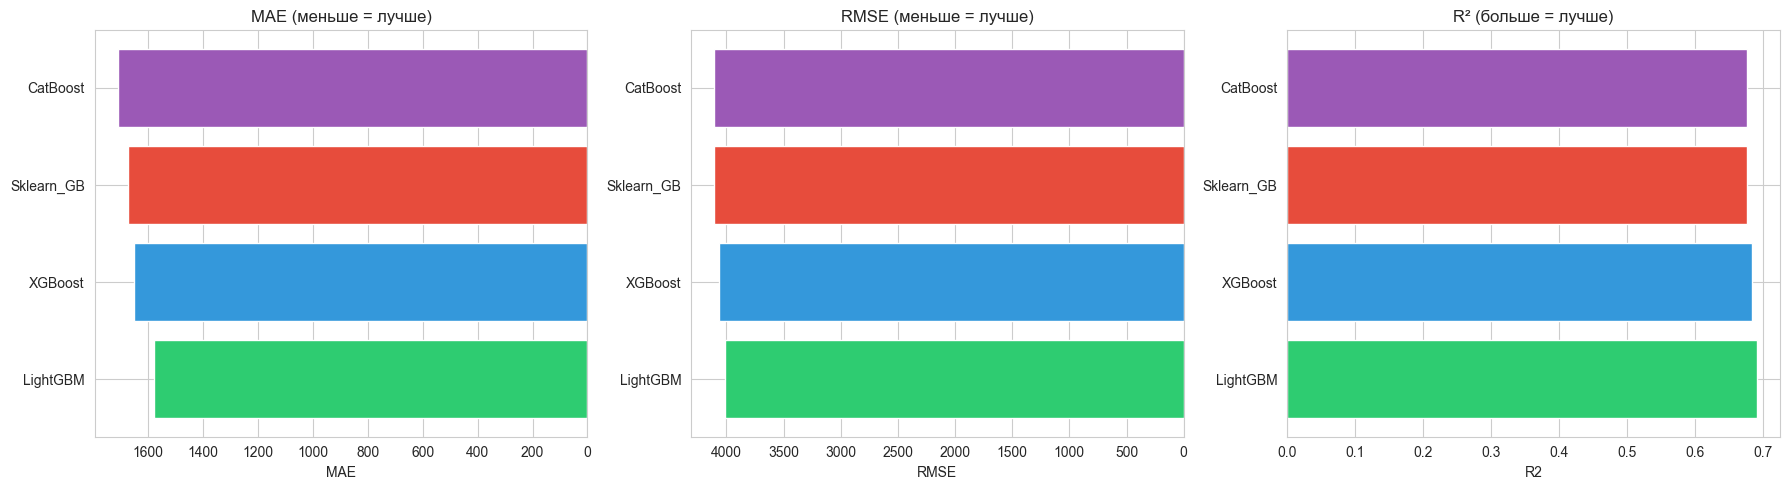

ПОБЕДИТЕЛЬ: LightGBM
   R² на тесте: 0.6902
   RMSE на тесте: $4,015.26


In [24]:
print("СРАВНЕНИЕ МОДЕЛЕЙ (дефолтные гиперпараметры)")
results_df = results_df.sort_values('R2', ascending=False)
print(results_df)

print("\nФИНАЛЬНОЕ СРАВНЕНИЕ (после настройки гиперпараметров)")
results_tuned_df = pd.DataFrame(results_tuned).T
results_tuned_df = results_tuned_df.sort_values('R2', ascending=False)
print(results_tuned_df)

# Визуализация финальных результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[idx].barh(results_tuned_df.index, results_tuned_df[metric],
                          color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(title)
    if metric in ['MAE', 'RMSE']:
        axes[idx].invert_xaxis()

plt.tight_layout()
plt.show()

# Финальный победитель
best_tuned = results_tuned_df['R2'].idxmax()
print(f"ПОБЕДИТЕЛЬ: {best_tuned}")
print(f"   R² на тесте: {results_tuned_df.loc[best_tuned, 'R2']:.4f}")
print(f"   RMSE на тесте: ${results_tuned_df.loc[best_tuned, 'RMSE']:,.2f}")

ВАЖНОСТЬ ПРИЗНАКОВ (лучшая модель)


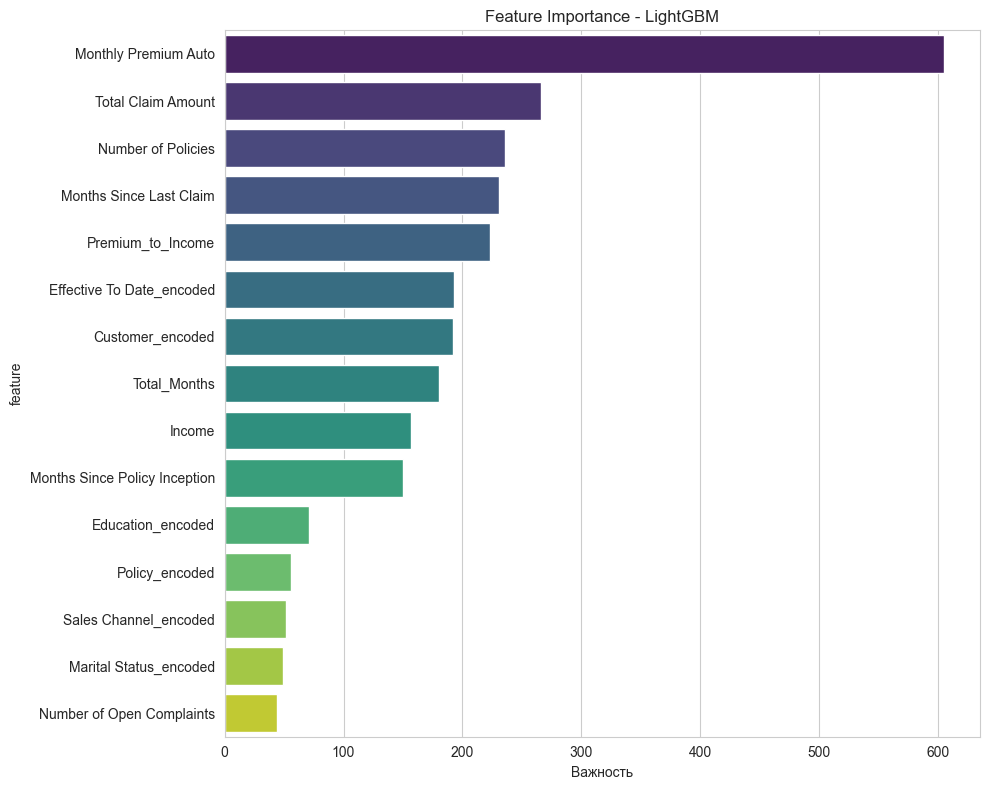

                      feature  importance
         Monthly Premium Auto         605
           Total Claim Amount         266
           Number of Policies         236
      Months Since Last Claim         231
            Premium_to_Income         223
    Effective To Date_encoded         193
             Customer_encoded         192
                 Total_Months         180
                       Income         157
Months Since Policy Inception         150
            Education_encoded          71
               Policy_encoded          56
        Sales Channel_encoded          52
       Marital Status_encoded          49
    Number of Open Complaints          44


In [25]:
print("ВАЖНОСТЬ ПРИЗНАКОВ (лучшая модель)")

# Выбираем модель с лучшим R²
best_model_name = results_tuned_df['R2'].idxmax()
best_model = {
    'Sklearn_GB': gb_tuned,
    'XGBoost': xgb_tuned,
    'LightGBM': lgb_tuned,
    'CatBoost': cat_tuned
}[best_model_name]

# Получаем важность признаков
if best_model_name == 'CatBoost':
    importances = best_model.get_feature_importance()
else:
    importances = best_model.feature_importances_

# Визуализация топ-15 признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title(f'Feature Importance - {best_model_name}')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))